### Trabalho 2 - Análise Estrutural de Redes Urbanas com OSMnx, NetworkX e Gephi

In [1]:
!pip install osmnx networkx matplotlib nxviz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.5/32.5 MB 18.4 MB/s  0:00:01 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 43.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 51.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7/7 [nxviz]━━━━━━━━━━━━ 4/7 [geopandas]


Foi escolhida a aréa da cidade de Natal para a criação do projeto visto a vasta quantidade e possibilidade de informação.

In [3]:
import networkx as nx
import nxviz as nv
from nxviz import annotate, highlights
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib as mpl
import osmnx as ox

In [4]:

# Inicializando com Natal-RN
place = "Natal, Rio Grande do Norte, Brazil"

G = ox.graph_from_place(place, network_type="drive")

print(G)
print(f"Número de nós: {G.number_of_nodes()}")
print(f"Número de arestas: {G.number_of_edges()}")


MultiDiGraph with 18587 nodes and 48213 edges
Número de nós: 18587
Número de arestas: 48213


In [ ]:
# Criar grafo não direcionado
G_undirected = nx.Graph(G)

# Medir o Grau
degree_dict = dict(G_undirected.degree())


# Top 10 nós por grau
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
top_degree

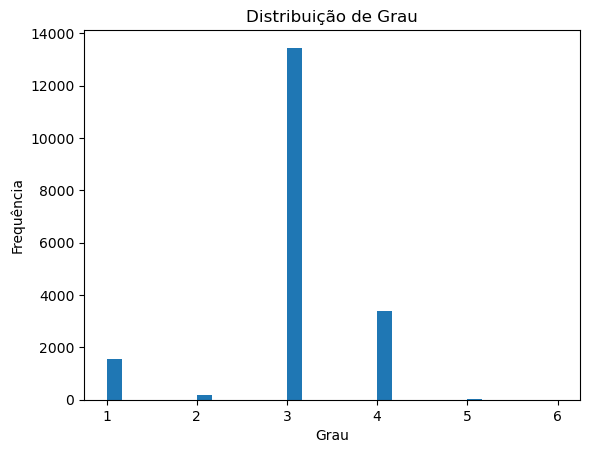

In [6]:
# Distribuição de Grau

degrees = list(degree_dict.values())

plt.hist(degrees, bins=30)
plt.title("Distribuição de Grau")
plt.xlabel("Grau")
plt.ylabel("Frequência")
plt.show()


In [7]:
# Criar HUB
top_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]
print(top_degree)

[(582071917, 6), (300389738, 5), (301415379, 5), (301427244, 5), (302599910, 5), (501791803, 5), (501791972, 5), (502407624, 5), (503426508, 5), (505492279, 5)]


In [10]:
# Criar o Betweenness
# como o betweenness é um processo bastante demorado, foi necessario restringir o tamanho
betweenness = nx.betweenness_centrality(G_undirected, k=100, normalized=True, seed=42)
print(betweenness)

{243207469: 0.03768612541401847, 243207479: 0.027773099050919518, 243207483: 0.022819263008029972, 243207565: 0.0832384525911278, 243207566: 4.5335650669877934e-05, 243207569: 0.00014347699105468552, 243207570: 0.00010914805497369372, 243207571: 0.0001350235704512046, 243207572: 0.09836766831661381, 243207954: 0.08369213246553132, 243207955: 0.00014631919860846329, 243207956: 2.7417109365057756e-05, 243207964: 0.0, 243212376: 0.04374156948030927, 300389738: 0.031172544268855837, 300389740: 0.03085350913131678, 300389746: 0.013304115521924901, 300389751: 0.017273119694883644, 300389753: 0.022340231207833575, 300389756: 0.0084608676833032, 300389758: 0.00024613813226229386, 300389761: 8.340059187516815e-05, 300392557: 0.031141148086626894, 300392559: 0.0003987158933700492, 300392561: 0.0003168770875504865, 300392563: 0.000322794114263869, 300392565: 0.0005574821998966805, 300392567: 0.0005659204137138564, 300392569: 0.000604433882846231, 300392571: 0.010888112225579078, 300392579: 0.0002

In [8]:
# Criar o  closeness
closeness = nx.closeness_centrality(G_undirected)
closeness

{243207469: 0.013475380930008642,
 243207479: 0.013543034438334963,
 243207483: 0.013591085721974327,
 243207565: 0.014296219263051664,
 243207566: 0.014133431885618514,
 243207569: 0.014369922282116228,
 243207570: 0.014297813940714768,
 243207571: 0.01442228602467603,
 243207572: 0.014499650498040292,
 243207954: 0.014203735645140459,
 243207955: 0.014089749566944504,
 243207956: 0.013938228136682529,
 243207964: 0.013649185242194826,
 243212376: 0.013455518456633354,
 300389738: 0.014588685566180874,
 300389740: 0.014551906052280694,
 300389746: 0.015767764398074546,
 300389751: 0.014551188302679749,
 300389753: 0.014555108305793537,
 300389756: 0.014703590457618201,
 300389758: 0.01438189796791659,
 300389761: 0.014345045186197699,
 300392557: 0.014545983888753668,
 300392559: 0.014342001089578475,
 300392561: 0.014173980153682368,
 300392563: 0.014392166003173308,
 300392565: 0.014453015645898784,
 300392567: 0.014207937670375235,
 300392569: 0.014346384998124302,
 300392571: 0.01

In [11]:
# Remove Loop

G_undirected.remove_edges_from(
    nx.selfloop_edges(G_undirected)
)

# Criar o k-score
core_number = nx.core_number(G_undirected)

# maior k-core
max_core = max(core_number.values())

k_core_graph = nx.k_core(G_undirected, k=max_core)

# Add atribute od graph

nx.set_node_attributes(G_undirected, degree_dict, "degree")
nx.set_node_attributes(G_undirected, betweenness, "betweenness")
nx.set_node_attributes(G_undirected, closeness, "closeness")
nx.set_node_attributes(G_undirected, core_number, "core_number")

In [12]:
#Exportar para o Gephi

ox.save_graphml(G, "rede_urbana.graphml")